
# Make sure to edit the first cell with the appropriate path

In [ ]:
import sys, os

#change the path to the directory that ctmc.py is located in on your system
sys.path.append(os.path.expanduser('~/source/discrete_states/'))

In [ ]:
from ctmc import ContinuousTimeMarkovChain as MC
from ctmc import normal_generator, gamma_generator, uniform_generator, cyclic_generator, detailed_balance_generator, arrhenius_pump_generator
from ctmc import HAS_JAX

import numpy as np
import matplotlib.pyplot as plt 

print(f"JAX available: {HAS_JAX}")

In [32]:
#you can start by making a bespoke rate equation if you want. 
R = abs(np.empty((3,3)))
# we can set the rates by hand, to be DB
E_0 = 1
E_1 = 2
E_2 = 3
R[0,1] = np.exp(-E_1+E_0) 
R[1,0] = 1/R[0,1]
R[0,2] = np.exp(-E_2+E_0) 
R[2,0] = 1/R[0,2]
R[1,2] = np.exp(-E_2+E_1)
R[2,1] = np.exp(-E_2+E_1)

# and for fun, let's add something non DB
R[0,2] *= np.exp(-2)

#the rate matrix looks like
print(R)

[[1.00000000e+02 3.67879441e-01 1.83156389e-02]
 [2.71828183e+00 1.00000000e+02 3.67879441e-01]
 [7.38905610e+00 3.67879441e-01 1.00000000e+00]]


In [33]:
# now, we can instantiate this into a CTMC object
machine_R = MC(R=R) 
# lets look at R again, now as an atrribute of machine_R
print(machine_R.R)
#you should see that the diagonals have been rectified to be a proper CTMC matrix, and the scale has been set so the 
# max output from any state is -1. this happend whenever we instantiate a new CTMC object automatically.
print(f'the scaling factor was {machine_R.scale}')


[[-0.04978707  0.04742587  0.0023612 ]
 [ 0.35043244 -0.39785831  0.04742587]
 [ 0.95257413  0.04742587 -1.        ]]
the scaling factor was 0.07756935540102092


In [34]:
# you can also make use of a generator_function to make a rate matrix that follows some particular sampling rules:

#make 1 machines with 10 states, each transition rate will be sampled from the same normal distribution
# the default is mu=0, sigma=1
#machine = MC(generator=normal_generator, S=10, N=1)
#but they can also be passed as arguments
#machine = MC(generator=normal_generator, S=4, N=1, mu=10, sigma=5)


#make 1 machines with 5 states, generated using the "cyclic" generator fo transition rates. max_jumps means a state can only jump to next nearest neighbor state
# this should impose a geometry on the states
machine = MC(generator=cyclic_generator, S=5, N=1, max_jump=2)


#make 1 machines with 3 states, generated using the arrhenious pump generator. Here, we select 3 transitions to be artifically pumped 
# beyond the normal DB transitions the arrheniosu equation gives. The pump strength is positive so as to be in the regime where ness and meps can be different
#machine = MC(generator=arrhenius_pump_generator, S=5, N=1, n_pumps=3, pump_strength=10)


In [35]:
s = 10
strength = -15
prob = .05
n = 1
npump = int(prob*(s**2-2))
machine = MC(generator=arrhenius_pump_generator, S=s, N=n, n_pumps=npump, pump_strength=strength)


In [36]:
np.argmin(machine.get_meps_deriv(states[0]))

7

In [37]:

max_prcnt = .5
min_prcnt = .1

states[0]

change = machine.get_meps_deriv(states[0]) / states[0]
change[change > max_prcnt] = max_prcnt
change[change < -max_prcnt] = -max_prcnt
change[(change>0) * (change<min_prcnt)] = min_prcnt
change[(change<0) * (change>min_prcnt)] = min_prcnt

states[0]*change


array([ 1.10357931e-07,  5.50504781e-06,  3.03729113e-02,  3.77071796e-02,
        7.58906912e-02,  1.23426939e-01,  1.83581895e-02, -1.25935252e-02,
        7.24441203e-03,  1.08706402e-02])

In [ ]:
max_prcnt

In [ ]:
np.minimum( max_prcnt, np.max(np.abs(change)))

In [ ]:
from time import sleep

states = [ machine.get_uniform() ]
eprs =[machine.get_epr(states[-1])]
p_log = []

max_prcnt = .99


for i in range(10_000):
    #dt = 2/  (2 + (i//1000 ))
    dt = 1
    change = machine.get_meps_deriv(states[-1]) / states[-1]
    #print(i,change)
    
    if np.all( np.isclose(change,0, atol=1E-4)):
        print(i,change)
        break

    #newmax = np.max(np.abs(change))
    #max_prcnt = np.maximum(np.minimum( max_prcnt, newmax ), 1E-3)
    newmax = max_prcnt * .9
    max_prcnt = np.maximum(newmax, 1E-3)

    min_prcnt = max_prcnt/10
    
    p_log.append( [ np.max(np.abs(change)),np.min(np.abs(change)) ] )
    
    #change[change > max_prcnt] = max_prcnt
    if np.any( change < -max_prcnt ):
        print(f'truncating step {i}', end='\r')
        change /= np.abs(np.min(change)/max_prcnt)
    else:   
        if np.any( np.abs(change) < min_prcnt ):
            print(f'bumpcating step {i}', end='\r')
            change /= (np.min(np.abs(change)) / min_prcnt)
        if np.any( change < -max_prcnt )
            change[change < -max_prcnt] = -max_prcnt

    #print(i,change)
    #print(i,states[-1])

    state = states[-1]*(1+dt*change)
    states.append( state/np.sum(state) )
    #print(i,states[-1])
    eprs.append( machine.get_epr(states[-1]))
    #sleep(.01)

In [ ]:
machine.get_meps_deriv(meps)

In [ ]:
machine.get_meps_deriv(states[-1])

In [1053]:
max_prcnt

0.001

In [1054]:
states[-1] - meps

array([ 3.74961558e-02, -2.16051795e-02, -8.32769965e-05, -2.06967209e-02,
       -8.30148798e-03, -4.44785259e-03,  4.15651066e-02, -2.90761819e-02,
        5.14993879e-03, -5.01467540e-07])

In [1055]:
machine.get_epr(states[-1])

0.00032841195725178264

In [1056]:
machine.get_epr(machine.meps)

0.0003457865932074012

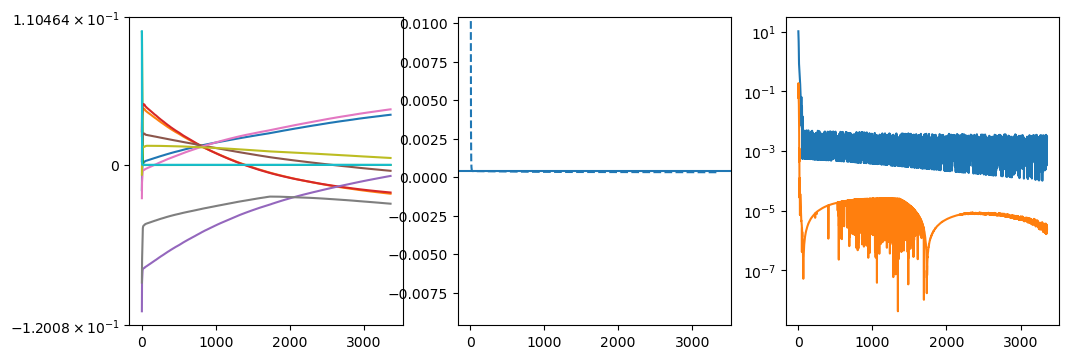

In [1057]:
fig, ax= plt.subplots(1,3, figsize=(12,4))
ax[0].plot(np.squeeze(states)- np.squeeze(machine.meps) )
#ax[0].hlines(np.squeeze(machine.meps), xmin=0, xmax=i, color='k')
#ax[1].plot(p_log)
ax[0].set_yscale('symlog')
ax[1].plot(eprs, '--')
ax[1].axhline(machine.get_epr(machine.ness))
ax[1].set_ylim(machine.get_epr(machine.ness)-.01, machine.get_epr(machine.ness)+.01)
ax[2].plot(p_log)
ax[2].set_yscale('log')

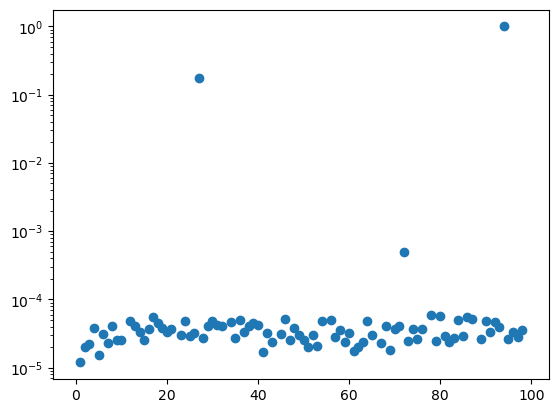

In [1044]:
plt.plot(machine.R.ravel(), linestyle='none', marker='o')
plt.yscale('log')

In [38]:
# find and the NESS state
ness = machine.get_ness()
# finds and the minimum entropy producing state
meps = machine.get_meps()
# returns a uniform state
unif = machine.get_uniform()


In [39]:
# for states, we can grab a variety of values, like the entropy produciton rate
print('epr:')
print(machine.get_epr(ness), machine.get_epr(meps), machine.get_epr(unif))
#activity (which is the sum of all (positive) transition rates)
print('activity:')
print(machine.get_activity(ness), machine.get_activity(meps), machine.get_activity(unif))
# or probability current (which is the total amount of probability flowing between states, note it is zero for the NESS state)
print('current:')
print(machine.get_prob_current(ness), machine.get_prob_current(meps), machine.get_prob_current(unif))

epr:
1.4877485794163461e-05 1.4287479381650196e-05 2.7969313045203905
activity:
5.31912779422458e-06 4.745933888906502e-06 0.19337182006426357
current:
1.6475620187912459e-06 1.9393708706108683e-06 0.38673612961712805


In [40]:
vals, vects = np.linalg.eig(machine.R.T)

In [44]:
vects[-3]

array([ 2.51814062e-06,  7.07106279e-01, -1.68571252e-06,  6.74505388e-07,
        2.30388910e-06,  2.78782215e-07, -9.54161081e-08,  1.16215900e-08,
        2.56094787e-07,  2.03178567e-07])

In [45]:
ness

array([3.40991387e-07, 9.99979653e-02, 1.00001413e-01, 9.99996214e-02,
       2.00001808e-01, 1.99998871e-01, 1.00000374e-01, 8.49774288e-07,
       1.00000587e-01, 9.99981698e-02])

In [43]:
for v in vects:
    print(sum(np.abs(machine.get_time_deriv(np.abs(v)))))

1.4142140314901124
0.08248030184279206
0.8003694066877546
0.004079358397077089
0.1428788679345838
2.425113704266319
0.5183834124617537
1.4274922112412515e-05
1.236374099295276
0.00019198483296368465


In [1087]:
t1 = 1/np.abs(np.diag(machine.R))
t1 = t1/np.sum(t1)
t1

array([1.76521295e-01, 1.14962675e-01, 2.27914387e-04, 1.07068901e-01,
       1.36511644e-01, 1.42110537e-01, 1.56894696e-01, 5.15262391e-02,
       1.14136181e-01, 3.99167251e-05])

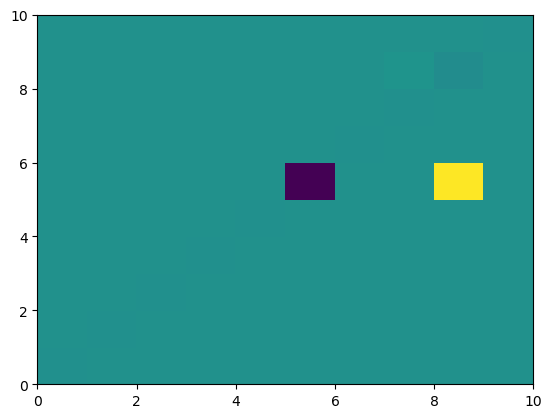

In [21]:
plt.pcolor(machine.R)

In [22]:
t1

NameError: name 't1' is not defined

In [1071]:
machine.ness

array([1.00741710e-01, 9.92963969e-02, 6.95868967e-04, 9.91280227e-02,
       2.00238638e-01, 9.97570930e-02, 1.00893496e-01, 1.98931573e-01,
       1.00288526e-01, 2.86753327e-05])

In [1020]:
machine.meps

array([1.18897618e-01, 7.83030081e-02, 5.93111719e-04, 7.49131655e-02,
       2.09601132e-01, 9.72842843e-02, 1.24971472e-01, 1.88084028e-01,
       1.07337231e-01, 1.49485845e-05])

epr:
1.7084433675458976e-05 1.6063340147914042e-05 1.477328464205881
activity:
9.530663890266348e-06 8.649231401850375e-06 0.10346842786706646
current:
3.611724572210493e-06 3.6619974180725395e-06 0.2069247762947136


3.611724572210493e-06 3.6619974180725395e-06 0.2069247762947136


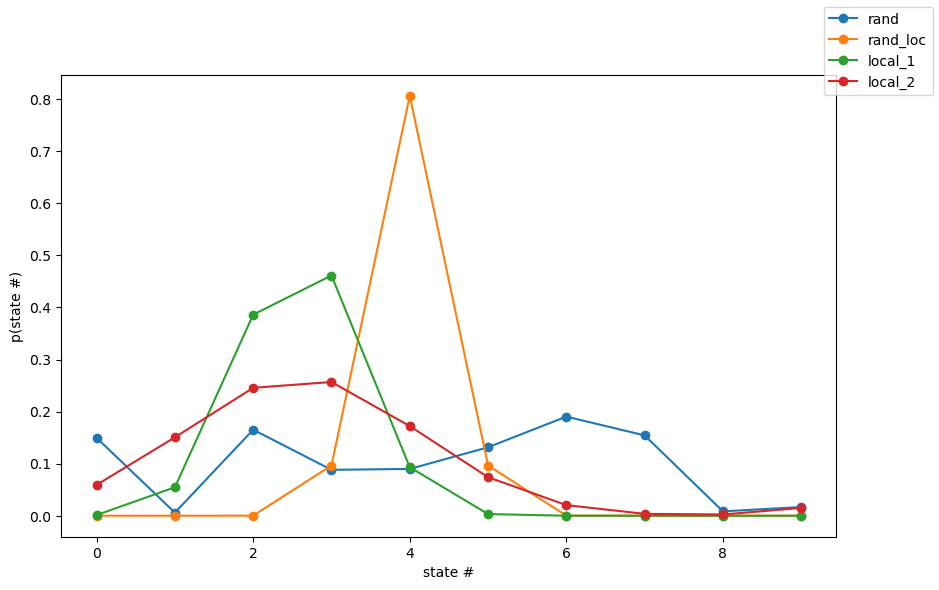

In [46]:
# returns a random state drawn from a uniform distrbution over all states
random = machine.get_random_state()

# returns a "localized" state which is basically a guassian centered on a particular state, putting the states on a ring, default is random peak and variance
random_local = machine.get_local_state()
# you can put in manual arguments too, though theres an annoying input issue with variances for now, requiring the array of a list input
hardcoded_local_1 = machine.get_local_state(mu=2.6, sigma= np.array([.75]))
hardcoded_local_2 = machine.get_local_state(mu=2.6, sigma= np.array([1.5]))


fig, ax = plt.subplots(figsize=(10,6))
states = [random, random_local, hardcoded_local_1, hardcoded_local_2]
labels = ['rand','rand_loc', 'local_1', 'local_2']
for s,l in zip(states, labels):
    ax.plot(range(machine.S), s.T, label=l, marker='o')
ax.set_xlabel('state #');
ax.set_ylabel('p(state #)');
fig.legend()


In [22]:
np.abs(vects[-1])/np.abs(vects[-1]).sum()

array([1.86798072e-07, 4.36136495e-06, 1.40325858e-01, 3.71622659e-03,
       2.14198431e-02, 1.17763947e-01, 2.87290051e-01, 2.02943538e-01,
       1.13267994e-01, 1.13267994e-01])

In [23]:
test_state1

NameError: name 'test_state1' is not defined

In [27]:
state = t1

In [28]:
state = machine.evolve_state(state, dt=dt)
state

array([ 1.19589422e-01,  2.52526120e-05,  7.46644661e-02,  1.37358892e-01,
        1.66458098e-01,  1.61855709e-01,  6.14748512e-02, -3.91321081e-07,
        1.33720962e-01,  1.44852738e-01])

found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking absolute value
found negative state, taking abs

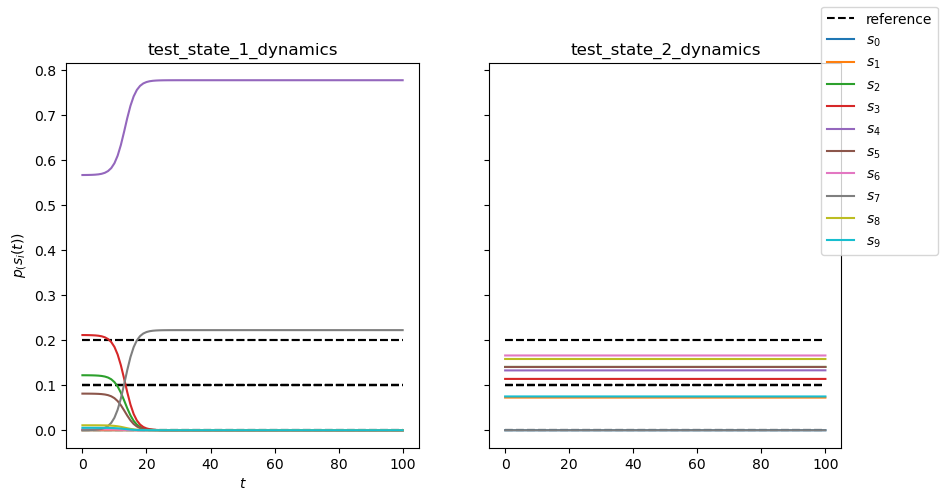

In [51]:
# and, we can evolve these states according to the rate matrix:
#test_state = random_local

t1 = 1/np.abs(np.diag(machine.R))
t1 = t1/np.sum(t1)

test_state1 = np.abs(vects[-1])/np.abs(vects[-1]).sum()
test_state2 = t1
reference_state = ness

T = 100
dt = 3

states = [test_state1]
states2 = [test_state2]

for i in range(T):
    states.append(machine.evolve_state(states[-1], dt=dt))
    states2.append(machine.evolve_state(states2[-1], dt=dt))
    

fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)

ax[0].hlines(reference_state, xmin=0, xmax=T, colors='k', linestyle='--', label='reference')
ax[1].hlines(reference_state, xmin=0, xmax=T, colors='k', linestyle='--')

ax[0].plot(np.squeeze(states))
ax[1].plot(np.squeeze(states2),label=[f'$s_{i}$' for i in range(test_state1.size)])
ax[0].set_xlabel('$t$')
ax[0].set_ylabel('$p_(s_i(t))$')

ax[0].set_title('test_state_1_dynamics');
ax[1].set_title('test_state_2_dynamics');
fig.legend();

In [11]:
# all of these things also work with ensembles of machines, for example...

# make an ensemble of 100 machines with 50 states each, generated using the default uniform generator for transition rates
#machines = MC(S=50, N=100)

# or whatever generator we want, here is an example of the arrhenious pump
s = 10
strength = -25
prob = .05
n = 100
npump = int(prob*(s**2-2))
machines = MC(generator=arrhenius_pump_generator, S=s, N=n, n_pumps=npump, pump_strength=strength)
machines.analytic_threshhold = 65


In [12]:
%%time

ness_100 = machines.get_ness()
print('ness done')
meps_100 = machines.get_meps()
print('meps done')


unif_100 = machines.get_uniform()
print('ness done')
ness_epr = machines.get_epr(ness_100)
meps_epr = machines.get_epr(meps_100)
unif_epr = machines.get_epr(unif_100)
print('ness done')

ness_activity = machines.get_activity(ness_100)
meps_activity = machines.get_activity(meps_100)
unif_activity = machines.get_activity(unif_100)
print('ness done')


ness didnt converge after 50000 iterations in 7 machines
ness done
meps didnt converge after 50000 iterations in 41 machines
mepr didnt converge after 50000 iterations in 3 machines
meps done
ness done
ness done
ness done
CPU times: user 7.63 s, sys: 4.06 ms, total: 7.63 s
Wall time: 7.64 s


In [ ]:
(np.abs(machines.get_meps_deriv(meps_100))/meps_100).max(axis=-1).argmax()

In [13]:
meps_d = machines.get_meps(diagnostic=True)

rewinding 97 states to avoid negative states at iteration 0
rewinding 95 states to avoid negative states at iteration 1
rewinding 96 states to avoid negative states at iteration 2
rewinding 92 states to avoid negative states at iteration 3
partially rewinding 1 states to avoid EPR increase at iteration 3
rewinding 86 states to avoid negative states at iteration 4
partially rewinding 2 states to avoid EPR increase at iteration 4
rewinding 81 states to avoid negative states at iteration 5
partially rewinding 1 states to avoid EPR increase at iteration 5
rewinding 76 states to avoid negative states at iteration 6
rewinding 67 states to avoid negative states at iteration 7
partially rewinding 1 states to avoid EPR increase at iteration 7
rewinding 62 states to avoid negative states at iteration 8
partially rewinding 2 states to avoid EPR increase at iteration 8
rewinding 50 states to avoid negative states at iteration 9
rewinding 42 states to avoid negative states at iteration 10
partially

In [12]:
ness_d = machines.get_ness(diagnostic=True)

ness didnt converge after 50000 iterations in 1 machines


In [ ]:
np.array(ness_d[1]).shape

In [ ]:
(ness_d[1][-1]-ness_d[1][-2])/(nes.max()

In [ ]:
plt.plot(np.array(ness_d[1])[:,~ness_d[-1],:][25_000:,0,:]);
plt.yscale('symlog')

In [ ]:
np.min(ness_d)
np.min(meps

In [ ]:
test_machine.get_ness()

In [ ]:
test_machine.get_meps()

In [18]:
nessDiff = np.diff(np.array(ness_d[1]), axis=0)
meps_diag = np.array(meps_d[1])
mepsDiff = np.diff(np.array(meps_d[1]), axis=0)
mepsEpr = (np.array(meps_d[0]))
mepsBool = meps_d[2]

In [50]:
machines.R[~mepsBool][0:1].shape

(1, 10, 10)

In [26]:
i = 0
mepsd = machines.get_meps_deriv(meps_diag[i,~mepsBool][0:1], R=machines.R[~mepsBool][0:1])

In [27]:
meps_diag[i,~mepsBool][0:1]

array([[1.00083493e-01, 1.00000164e-01, 1.00000052e-01, 1.00000150e-01,
        9.99998840e-02, 2.60626549e-01, 9.99162655e-02, 4.27764466e-10,
        9.96513153e-02, 3.97221269e-02]])

In [28]:
np.abs(mepsd[~mepsBool][0]) / meps_diag[i,~mepsBool][0:1]

array([[8.38095294e-04, 8.37272870e-04, 8.37271063e-04, 8.37274313e-04,
        8.37262587e-04, 1.08499555e-03, 8.30161537e-04, 2.56554182e+00,
        8.08660132e-04, 2.17786936e-02]])

In [29]:
np.isclose( 0, np.abs(mepsd[~mepsBool][0]) / meps_diag[i,~mepsBool][0:1], atol=1E-3)

array([[ True,  True,  True,  True,  True, False,  True, False,  True,
        False]])

In [24]:
1E-6 * np.get_time_deriv(self.get_uniform())

AttributeError: module 'numpy' has no attribute 'get_time_deriv'

In [25]:
test_m.get_meps()

NameError: name 'test_m' is not defined

In [ ]:
test_m.get_ness()

In [ ]:
test_m.get_epr(test_m.ness)

In [ ]:
test_m.get_epr(test_m.meps)

In [ ]:
mepsEpr.min(axis=0) - mepsEpr[-1]

In [ ]:
mepsEpr[-1]

In [ ]:
for item in (meps_d[1][-10:,~mepsBool][:,0]):
    print(test_m.get_epr(item))

In [ ]:
for item in (meps_d[1][13:25,mepsBool][:,0]):
    print(item.mean(), item.max(), item.min())

In [ ]:
state.shape

In [ ]:
state = np.array(meps_d[1])[-1]

mepsd = np.abs(machines.get_meps_deriv(state))/np.maximum(1E-12,state)

In [ ]:
(mepsd > 1E-4).sum(axis=-1)

In [ ]:
sum(mepsEpr[0]-mepsEpr < 0)

In [ ]:
mepsEpr.shape

In [22]:
mepsEpr.shape

(50001, 100)

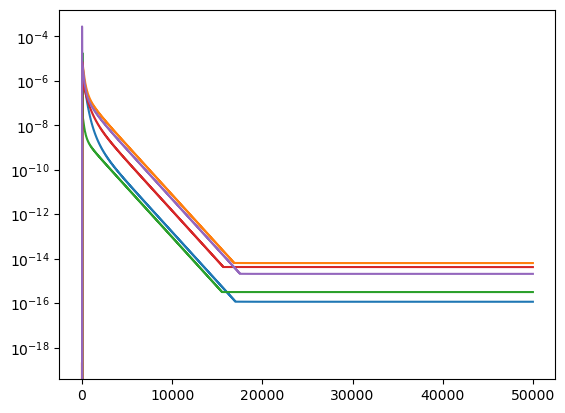

In [19]:
plt.plot(-(np.diff(mepsEpr, axis=0))[:,~mepsBool][:,:]);

plt.yscale('log')

In [16]:
plt.plot(-(np.diff(mepsEpr, axis=0))[:,mepsBool][:,:]);

plt.yscale('log')


NameError: name 'mepsEpr' is not defined

In [17]:
plt.plot(mepsEpr[:,mepsBool][10_000:]);
plt.yscale('log')

NameError: name 'mepsEpr' is not defined

In [ ]:
test_machine.get_epr(test_machine.meps)

In [ ]:
test_machine.get_epr(test_machine.ness)

In [ ]:
meps_epr[np.argmin(diff)]

In [ ]:
ness_epr[np.argmin(diff)]

In [ ]:
test_machine.get_epr(meps_100[np.argmin(diff)])

In [ ]:
#meps_100[np.argmin(ness_epr)]
ness_100[(~np.isclose(ness_100.sum(axis=-1), 1))].sum(axis=-1)



In [ ]:
sum(~validBool)

In [ ]:
for i in range(10):
    print(machines.R[np.argmin(ness_epr)][i,:])

In [ ]:
sdiff = np.abs(diff)< 1E-7
sum(sdiff)

In [ ]:
np.argmin(ness_epr)

In [ ]:
plt.scatter(meps_epr[sdiff], diff[sdiff])
plt.xscale('log')

plt.yscale('symlog')

In [ ]:
machines.R[np.argmin(diff)]

In [ ]:
test_machine.evolve_state(

In [ ]:
test_machine.ness

In [ ]:
test_machine.meps

In [ ]:
# and, we can evolve these states according to the rate matrix:

T = 25
dt = .5

states = [test_machine.ness]
meps_states = [test_machine.meps]

test_state = states[-1]
meps_state = meps_states[-1]

for i in range(T):
    test_state = test_machine.evolve_state(test_state, dt=dt)
    meps_state = test_machine.evolve_state(meps_state, dt=dt)
    
    states.append(test_state)
    meps_states.append(meps_state)
    

fig, ax = plt.subplots(1,2, figsize=(10,5), sharex=True, sharey=True)

#ax[0].hlines(ness, xmin=0, xmax=T, colors='k', linestyle='--', label='ness')
#ax[1].hlines(ness, xmin=0, xmax=T, colors='k', linestyle='--')
print( np.diff(np.squeeze(states), axis=0).shape )
ax[0].plot( np.diff(np.squeeze(states), axis=0) )
ax[1].plot( np.diff(np.squeeze(meps_states),axis=0),label=[f'$s_{i}$' for i in range(test_state.size)])
ax[0].set_xlabel('$t$')
ax[0].set_ylabel('$p_(s_i(t))$')

ax[0].set_title('test_state_dynamics');
ax[1].set_title('meps_state_dynamics');
fig.legend();

#ax[0].set_yscale('log')

In [ ]:
test_machine.get_epr(meps_states[-1])

In [ ]:
test_machine.get_epr(test_machine.meps)

In [ ]:
test_machine.get_epr(test_machine.ness)

In [ ]:
test_machine.get_epr(states[0])

In [ ]:
test_machine.get_epr(states[-1])

In [ ]:
np.min( np.abs(machine.R))

In [ ]:
np.max(machine.R)

In [ ]:

fig, ax = plt.subplots(1,2,figsize=(14,7))
diff = ness_epr/meps_epr-1



validBool = diff > 0
vdiff = diff[validBool]


print(sum( ~validBool))
print(sum(diff < 0))

print(np.std(diff), np.mean(diff), np.min(diff), np.max(diff))
print(np.std(vdiff), np.mean(vdiff), np.min(vdiff), np.max(vdiff))

#print(sum(idx))
ax[0].scatter(meps_epr, diff, alpha=.1)
ax[1].scatter(meps_epr[validBool], diff[validBool], alpha=.1)

#x = np.linspace(meps_epr.min(), meps_epr.max(), 2)
#plt.plot(x,x, color='k')

for a in ax.ravel():
    a.set_title('EPR differences')
    a.set_xscale('log')
    a.set_yscale('log')
    a.set_xlabel('MEPS EPR')
    a.set_ylabel('NESS EPR- MEPS EPR')
    #a.set_xlim(10E-20,1)

In [ ]:

fig, ax = plt.subplots(1,2,figsize=(14,7))
diff = ness_epr/meps_epr-1



validBool = diff > 0
vdiff = diff[validBool]


print(sum( ~validBool))
print(sum(diff < 0))

print(np.std(diff), np.mean(diff), np.min(diff), np.max(diff))
print(np.std(vdiff), np.mean(vdiff), np.min(vdiff), np.max(vdiff))

#print(sum(idx))
ax[0].scatter(meps_epr, diff, alpha=.1)
ax[1].scatter(meps_epr[validBool], diff[validBool], alpha=.1)

#x = np.linspace(meps_epr.min(), meps_epr.max(), 2)
#plt.plot(x,x, color='k')

for a in ax.ravel():
    a.set_title('EPR differences')
    a.set_xscale('log')
    a.set_yscale('log')
    a.set_xlabel('MEPS EPR')
    a.set_ylabel('NESS EPR- MEPS EPR')
    #a.set_xlim(10E-20,1)

In [ ]:

fig, ax = plt.subplots(1,2,figsize=(14,7))
diff = ness_epr-meps_epr



validBool = diff > 0
vdiff = diff[validBool]


print(sum( ~validBool))
print(sum(diff < 0))

print(np.std(diff), np.mean(diff), np.min(diff), np.max(diff))
print(np.std(vdiff), np.mean(vdiff), np.min(vdiff), np.max(vdiff))

#print(sum(idx))
ax[0].scatter(meps_epr, diff, alpha=.1)
ax[1].scatter(meps_epr[validBool], diff[validBool], alpha=.1)

#x = np.linspace(meps_epr.min(), meps_epr.max(), 2)
#plt.plot(x,x, color='k')

for a in ax.ravel():
    a.set_title('EPR differences')
    a.set_xscale('log')
    a.set_yscale('log')
    a.set_xlabel('MEPS EPR')
    a.set_ylabel('NESS EPR- MEPS EPR')
    #a.set_xlim(10E-20,1)


In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,7))
ax[0].scatter(meps_epr, unif_epr-meps_epr, label='unif', alpha=.8)
ax[0].scatter(meps_epr, ness_epr-meps_epr, label='ness', alpha=.8)


ax[1].scatter(meps_epr, unif_activity)
ax[1].scatter(meps_epr, ness_activity)
ax[1].scatter(meps_epr, meps_activity, label='meps')

ax[0].set_xlabel('MEPR')
ax[1].set_xlabel('MEPR')
ax[0].set_title('EPR- MEPR')
ax[1].set_title('activity')

fig.legend()

In [ ]:
%%time
# example of doing a sweep over many different kind of generators with different S and N, and saving some of the data. The NESS calculating will become numeric if the matrices get
# too large to invert exactly
SS = [3, 6, 20, 100, 250]
trials = [300, 300, 300, 300, 300]

normal_output, uniform_output, gamma_output, cyclic_output, balanced_output = {}, {}, {}, {}, {}

for a in range(5):
    print(a)
    output = [normal_output, uniform_output, gamma_output, cyclic_output, balanced_output ][a]
    gen = [normal_generator, uniform_generator, gamma_generator, cyclic_generator, detailed_balance_generator][a]
    
    
    for s,trial in zip(SS,trials):
        p = MC(S=s, N=trial, generator=gen)
        p.verbose = False
        #R = [ np.random.uniform(0,1,(S,S)) for i in range(trials)]
        #for p,r in zip(procs,R):
        #    p.set_rate_matrix(r, max_rate=1)   
        dct = {'ness':p.get_epr(p.get_ness()), 
               'meps':p.get_epr(p.get_meps()), 
               'unif':p.get_epr(p.get_uniform()),
               'rand':p.get_epr(p.get_random_state()),
               'local':p.get_epr(p.get_local_state()),
               'N':trial, 'scale':p.scale, 
               'nm_dkl':p.dkl(p.ness,p.meps),'mn_dkl':p.dkl(p.meps,p.ness)}
        
        output[f'{p.S}'] = dct


In [ ]:
# some example data calls


nstates=['3','6', '100']

plot_generator = normal_output

fig,axs = plt.subplots(1,len(nstates), sharey=True, sharex=True)


state_types = ['local','ness','unif']

for ax, n in zip(axs, nstates):

    for state_type in state_types:
        meps_epr = plot_generator[n]['meps']
        ax.scatter(meps_epr, plot_generator[n][state_type]-meps_epr, label=state_type)

    ax.set_title(f'N={n}')
    ax.legend()
    ax.set_xlabel('MEPS EPR')
    ax.set_ylabel('EPR-MEPS_EPR')

    ax.set_yscale('log')


